In [3]:
import io
import requests
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

YEAR = 2025
con = duckdb.connect()

con.execute("INSTALL httpfs; LOAD httpfs;")

# Генерируем список URL-адресов за все 3 месяца осени
urls = [
    f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{YEAR}-{m:02d}.parquet"
    for m in range(9, 12)
]

# Формируем SQL-запрос со списком URL
urls_str = ", ".join([f"'{url}'" for url in urls])
query = f"SELECT * FROM read_parquet([{urls_str}])"

print("Processing...")
taxi = con.execute(query).df()

print(f"Taxi rows: {len(taxi):,}")

Processing...
Taxi rows: 12,861,158


In [4]:
taxi.info()

<class 'pandas.DataFrame'>
RangeIndex: 12861158 entries, 0 to 12861157
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        Int64         
 4   trip_distance          float64       
 5   RatecodeID             Int64         
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64 

In [5]:
taxi.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,N,138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75
1,2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,N,93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.00,0.00
2,2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,N,68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.00,0.75
3,2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,N,234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.00,0.75
4,2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,N,230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.00,0.75


- `VendorID` - код, указывающий на поставщика TPEP, предоставившего запись.
- `tpep_pickup_datetime` - дата и время, когда таксометр был включён.
- `tpep_dropoff_datetime` - дата и время, когда таксометр был выключен.
- `passenger_count` - количество пассажиров в автомобиле.
- `trip_distance` - пройденное расстояние в милях по данным таксометра.
- `RatecodeID` - итоговый код тарифа, действовавший на момент окончания поездки.
- `store_and_fwd_flag` - флаг, указывающий, была ли запись о поездке сохранена в памяти автомобиля перед отправкой поставщику (режим «store and forward»), поскольку транспортное средство не имело соединения с сервером.
- `PULocationID` - код зоны TLC, в которой был включён таксометр (зона посадки).
- `DOLocationID` - код зоны TLC, в которой был выключен таксометр (зона высадки).
- `payment_type` - числовой код, обозначающий способ оплаты поездки пассажиром.
- `fare_amount` - сумма за проезд, рассчитанная по времени и расстоянию согласно таксометру.
- `extra` - дополнительные сборы и наценки.
- `mta_tax` - налог, который автоматически начисляется в зависимости от используемого тарифа.
- `tip_amount` - сумма чаевых (заполняется автоматически для оплаты кредитной картой; наличные чаевые не учитываются).
- `tolls_amount` - общая сумма всех дорожных сборов (платежей за проезд по платным дорогам), уплаченных в поездке.
- `improvement_surcharge` - сбор на улучшение сервиса, взимаемый при включении таксометра.
- `total_amount` - общая сумма, выставленная пассажиру (не включает наличные чаевые).
- `congestion_surcharge` - общая сумма сбора за пробки, взимаемого в штате Нью-Йорк (NYS congestion surcharge).
- `airport_fee` - сбор за посадку только в аэропортах LaGuardia и John F. Kennedy.

In [6]:
# Trip duration in minutes

taxi["trip_duration_min"] = (
    taxi["tpep_dropoff_datetime"]
    - taxi["tpep_pickup_datetime"]
).dt.total_seconds() / 60


# Hour-level grain

taxi["pickup_hour"] = taxi[
    "tpep_pickup_datetime"
].dt.floor("h")

In [7]:
taxi.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_hour
count,1.286116e+07,12861158,12861158,9788336.0,1.286116e+07,9788336.0,1.286116e+07,1.286116e+07,1.286116e+07,1.286116e+07,...,1.286116e+07,1.286116e+07,1.286116e+07,1.286116e+07,1.286116e+07,9.788336e+06,9.788336e+06,1.286116e+07,1.286116e+07,12861158
mean,1.879282e+00,2025-10-16 08:57:35.908215,2025-10-16 09:16:08.523856,1.275346,6.689974e+00,4.089017,1.616698e+02,1.613727e+02,9.244567e-01,1.819918e+01,...,4.781855e-01,2.905148e+00,5.223995e-01,9.456430e-01,2.677635e+01,2.170378e+00,1.466304e-01,5.349756e-01,1.854359e+01,2025-10-16 08:27:33.607396
min,1.000000e+00,2008-12-31 23:04:21,2008-12-31 23:32:25,0.0,0.000000e+00,1.0,1.000000e+00,1.000000e+00,0.000000e+00,-1.508700e+03,...,-5.000000e-01,-3.333300e+02,-1.150500e+02,-1.000000e+00,-1.514450e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01,-7.073167e+02,2008-12-31 23:00:00
25%,2.000000e+00,2025-09-23 20:20:25.250000,2025-09-23 20:38:10,1.0,1.060000e+00,1.0,1.140000e+02,1.070000e+02,1.000000e+00,8.600000e+00,...,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.545000e+01,2.500000e+00,0.000000e+00,0.000000e+00,8.633333e+00,2025-09-23 20:00:00
50%,2.000000e+00,2025-10-16 17:18:57,2025-10-16 17:44:30,1.0,1.900000e+00,1.0,1.610000e+02,1.620000e+02,1.000000e+00,1.358000e+01,...,5.000000e-01,2.030000e+00,0.000000e+00,1.000000e+00,2.142000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.450000e+01,2025-10-16 17:00:00
75%,2.000000e+00,2025-11-07 15:15:15,2025-11-07 15:37:27,1.0,3.880000e+00,1.0,2.330000e+02,2.340000e+02,1.000000e+00,2.271000e+01,...,5.000000e-01,4.010000e+00,0.000000e+00,1.000000e+00,3.106000e+01,2.500000e+00,0.000000e+00,7.500000e-01,2.316667e+01,2025-11-07 15:00:00
max,7.000000e+00,2025-11-30 23:59:59,2025-12-01 21:41:00,9.0,3.186086e+05,99.0,2.650000e+02,2.650000e+02,4.000000e+00,3.238003e+05,...,1.050000e+01,5.750000e+02,3.000000e+02,2.500000e+00,3.238202e+05,2.500000e+00,6.750000e+00,1.750000e+00,9.907050e+03,2025-11-30 23:00:00
std,7.431426e-01,NaN,NaN,0.691041,6.488316e+02,16.823097,6.632198e+01,7.058761e+01,7.305602e-01,9.241144e+01,...,1.332603e-01,4.045410e+00,2.158638e+00,2.855600e-01,9.342048e+01,9.538255e-01,5.305453e-01,3.555277e-01,2.698080e+01,NaN


In [8]:
print("\n=== DATA QUALITY ===")

print(
    "Null pickup timestamps:",
    taxi["tpep_pickup_datetime"].isna().sum()
)

print(
    "Null fare:",
    taxi["fare_amount"].isna().sum()
)

print(
    "Null total sum:",
    taxi["total_amount"].isna().sum()
)

print(
    "Negative fares:",
    (taxi["fare_amount"] < 0).sum()
)

print(
    "Negative total fee:",
    (taxi["total_amount"] < 0).sum()
)

print(
    "Zero distance:",
    (taxi["trip_distance"] <= 0).sum()
)

print(
    "Impossible duration:",
    (
        (taxi["trip_duration_min"] <= 0)
        | (taxi["trip_duration_min"] > 300)  # more than 5 hours
    ).sum()
)

print(
    "Taxi without passengers:",
    (taxi["passenger_count"] == 0).sum()
)


=== DATA QUALITY ===
Null pickup timestamps: 0
Null fare: 0
Null total sum: 0
Negative fares: 969118
Negative total fee: 314146
Zero distance: 359502
Impossible duration: 191401
Taxi without passengers: 64438


In [9]:
# Clean data

autumn_start = pd.Timestamp("2025-09-01")
autumn_end = pd.Timestamp("2025-12-01")  # строго меньше, чтобы включить 30.11.2025

clean_taxi = taxi[
    taxi["tpep_pickup_datetime"].notna()
    & taxi["tpep_dropoff_datetime"].notna()
    & (taxi["tpep_pickup_datetime"] >= autumn_start)
    & (taxi["tpep_pickup_datetime"] < autumn_end)
    & (taxi["tpep_dropoff_datetime"] >= autumn_start)
    & (taxi["tpep_dropoff_datetime"] < autumn_end)
    & taxi["fare_amount"].notna()
    & (taxi["fare_amount"] > 0)
    & (taxi["trip_distance"] > 0)
    & (taxi["trip_duration_min"] > 0)
    & (taxi["trip_duration_min"] <= 300)
    & (taxi["passenger_count"] > 0)
].copy()


print(
    f"Rows after cleaning: {len(clean_taxi):,}",
    f"\nDeleted {len(taxi)-len(clean_taxi):,} lines"
)

Rows after cleaning: 9,225,994 
Deleted 3,635,164 lines


In [10]:
# Aggreagate by hours
 
clean_taxi["tpep_pickup_datetime"] = pd.to_datetime(clean_taxi["tpep_pickup_datetime"], errors="coerce")
clean_taxi["tpep_dropoff_datetime"] = pd.to_datetime(clean_taxi["tpep_dropoff_datetime"], errors="coerce")

# Создаём час суток: 0, 1, 2, ..., 23
clean_taxi["pickup_hour"] = clean_taxi["tpep_pickup_datetime"].dt.hour

hourly_taxi = (
    clean_taxi
    .groupby("pickup_hour")
    .agg(
        trips=("fare_amount", "size"),
        avg_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        avg_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration_min", "mean"),
    )
    .reset_index()
)

# Чтобы всегда было ровно 24 часа, даже если каких-то часов нет в данных
hourly_taxi = (
    hourly_taxi
    .set_index("pickup_hour")
    .reindex(range(24))
    .rename_axis("pickup_hour")
    .reset_index()
)

# Пропущенные часы = 0 поездок
hourly_taxi["trips"] = hourly_taxi["trips"].fillna(0).astype(int)

# Преобразуем, чтобы посчитать среднее число поездок, а не общее за 3 месяца
clean_taxi["pickup_date"] = clean_taxi["tpep_pickup_datetime"].dt.date

# Считаем кол-во поездок для каждой пары (дата, час)
daily_hourly = (
    clean_taxi
    .groupby(["pickup_date", "pickup_hour"])
    .size()
    .reset_index(name="daily_trips")
)

# Считаем среднее и медиану по часам на основе дневных данных
hourly_avg_trips = (
    daily_hourly
    .groupby("pickup_hour")["daily_trips"]
    .agg(["mean", "median"])
    .round(1)
    .rename(columns={"mean": "avg_trips_per_day", "median": "median_trips_per_day"})
    .reindex(range(24), fill_value=0) # Добиваем до 24 часов
    .reset_index()
)

# Мерджим с остальными метриками 
hourly_taxi = hourly_taxi.merge(hourly_avg_trips, on="pickup_hour", how="left")

hourly_taxi.head(3)

,pickup_hour,trips,avg_fare,median_fare,avg_distance,avg_duration,avg_trips_per_day,median_trips_per_day
0,0,234722,20.745602,14.2,4.016061,14.780381,2579.4,1882.0
1,1,151913,17.986943,12.8,3.340497,12.997643,1669.4,875.0
2,2,95906,16.382693,12.1,2.968314,11.974166,1053.9,445.0


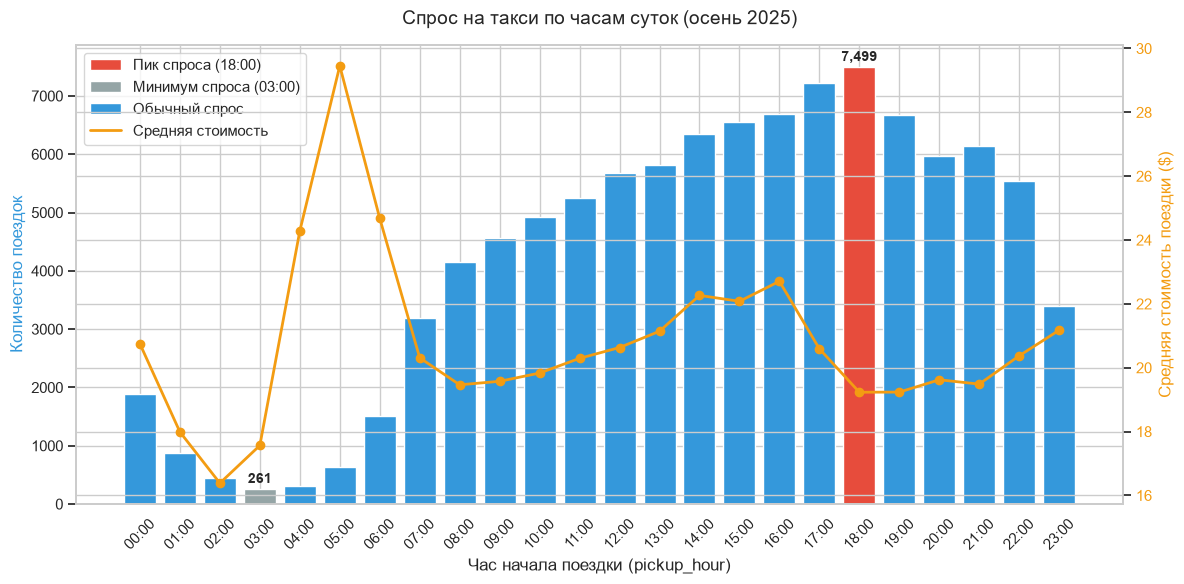

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Визуализация спроса по часам 
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Раскрашиваем столбцы: выделяем пик и провал
colors = sns.color_palette("Blues_d", len(hourly_taxi))
max_hour = hourly_taxi.loc[hourly_taxi["median_trips_per_day"].idxmax(), "pickup_hour"]
min_hour = hourly_taxi.loc[hourly_taxi["median_trips_per_day"].idxmin(), "pickup_hour"]

bar_colors = []
for h in hourly_taxi["pickup_hour"]:
    if h == max_hour:
        bar_colors.append("#e74c3c")  # пик - красный
    elif h == min_hour:
        bar_colors.append("#95a5a6")  # минимум - серый
    else:
        bar_colors.append("#3498db")  # обычное - синий

bars = ax1.bar(
    hourly_taxi["pickup_hour"],
    hourly_taxi["median_trips_per_day"],
    color=bar_colors,
    edgecolor="white",
)

ax1.set_xlabel("Час начала поездки (pickup_hour)", fontsize=12)
ax1.set_ylabel("Количество поездок", fontsize=12, color="#3498db")
ax1.set_title("Спрос на такси по часам суток (осень 2025)", fontsize=14, pad=15)
ax1.set_xticks(hourly_taxi["pickup_hour"])
ax1.set_xticklabels([f"{int(h):02d}:00" for h in hourly_taxi["pickup_hour"]], rotation=45)

# Подписи значений над столбцами (только для пика и минимума)
for bar in bars:
    hour = hourly_taxi.iloc[list(bars).index(bar)]["pickup_hour"]
    if hour in (max_hour, min_hour):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )

# Дополнительная линия - средняя стоимость поездки (на правой оси)
ax2 = ax1.twinx()
ax2.plot(
    hourly_taxi["pickup_hour"],
    hourly_taxi["avg_fare"],
    color="#f39c12",
    marker="o",
    linewidth=2,
    label="Средняя стоимость",
)
ax2.set_ylabel("Средняя стоимость поездки ($)", fontsize=12, color="#f39c12")
ax2.tick_params(axis="y", labelcolor="#f39c12")

# Легенда
legend_elements = [
    Patch(facecolor="#e74c3c", label=f"Пик спроса ({int(max_hour):02d}:00)"),
    Patch(facecolor="#95a5a6", label=f"Минимум спроса ({int(min_hour):02d}:00)"),
    Patch(facecolor="#3498db", label="Обычный спрос"),
    plt.Line2D([0], [0], color="#f39c12", lw=2, label="Средняя стоимость"),
]
ax1.legend(handles=legend_elements, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
# Аналитическая сводка
print("Анализ спроса по часам")
print(
    f"Пик спроса: {int(max_hour):02d}:00 - "
    f"{hourly_taxi.loc[hourly_taxi['pickup_hour']==max_hour, 'median_trips_per_day'].iloc[0]:,} поездок"
)
print(
    f"Минимум: {int(min_hour):02d}:00 - "
    f"{hourly_taxi.loc[hourly_taxi['pickup_hour']==min_hour, 'median_trips_per_day'].iloc[0]:,} поездок"
)
print("\nТоп-3 часов по спросу:")
top3 = hourly_taxi.nlargest(3, "trips")
for _, row in top3.iterrows():
    print(f"  • {int(row['pickup_hour']):02d}:00 → {int(row['median_trips_per_day']):,} поездок, "
          f"ср. цена ${row['avg_fare']:.2f}")

print("\nХудшие 3 часа:")
bottom3 = hourly_taxi.nsmallest(3, "trips")
for _, row in bottom3.iterrows():
    print(f"  • {int(row['pickup_hour']):02d}:00 → {int(row['median_trips_per_day']):,} поездок")

Анализ спроса по часам
Пик спроса: 18:00 — 7,499.0 поездок
Минимум: 03:00 — 261.0 поездок

Топ-3 часов по спросу:
  • 18:00 → 7,499 поездок, ср. цена $19.23
  • 17:00 → 7,225 поездок, ср. цена $20.59
  • 16:00 → 6,688 поездок, ср. цена $22.71

Худшие 3 часа:
  • 04:00 → 316 поездок
  • 05:00 → 634 поездок
  • 03:00 → 261 поездок


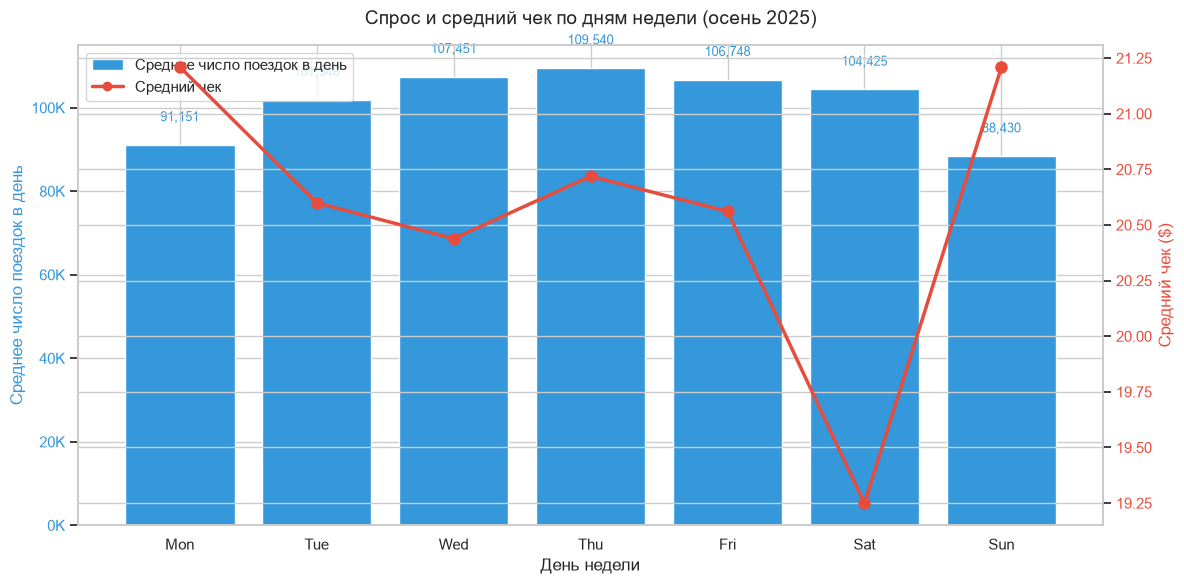

In [ ]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Добавляем день недели (0 = понедельник ... 6 = воскресенье)
clean_taxi["dow"] = clean_taxi["tpep_pickup_datetime"].dt.dayofweek
clean_taxi["dow_name"] = clean_taxi["tpep_pickup_datetime"].dt.day_name()
clean_taxi["pickup_date"] = clean_taxi["tpep_pickup_datetime"].dt.date

dow_stats = (
    clean_taxi
    .groupby(["dow", "dow_name"])
    .agg(
        trips=("fare_amount", "size"),
        avg_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
    )
    .reset_index()
    .sort_values("dow")
)

# Считаем количество уникальных дат для каждого дня недели
days_per_dow = clean_taxi.groupby("dow")["pickup_date"].nunique()

# Добавляем среднее число поездок в день
dow_stats["avg_trips_per_day"] = (
    dow_stats["trips"] / dow_stats["dow"].map(days_per_dow)
).round(0).astype(int)

# Сокращённые подписи для оси X
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы - среднее число поездок в день
bars = ax1.bar(
    dow_labels,
    dow_stats["avg_trips_per_day"],
    color="#3498db",
    edgecolor="white",
    label="Среднее число поездок в день",
)

ax1.set_xlabel("День недели", fontsize=12)
ax1.set_ylabel("Среднее число поездок в день", color="#3498db", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#3498db")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax1.set_title("Спрос и средний чек по дням недели (осень 2025)", fontsize=14, pad=15)

# Подписи значений
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5_000,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9, color="#3498db",
    )

# Линия - средний чек (правая ось)
ax2 = ax1.twinx()
ax2.plot(
    dow_labels,
    dow_stats["avg_fare"],
    color="#e74c3c",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Средний чек ($)",
)
ax2.set_ylabel("Средний чек ($)", color="#e74c3c", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#e74c3c")

# Общая легенда
legend = [
    Patch(facecolor="#3498db", label="Среднее число поездок в день"),
    Line2D([0], [0], color="#e74c3c", lw=2.5, marker="o", label="Средний чек"),
]
ax1.legend(handles=legend, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

In [14]:
# Считаем количество уникальных дней в датасете
num_days = clean_taxi["tpep_pickup_datetime"].dt.date.nunique()

# Поездки в аэропорт (Airport_fee > 0)
airport_taxi = (
    clean_taxi[clean_taxi["Airport_fee"] > 0]
    .groupby("pickup_hour")
    .agg(
        airport_trips=("fare_amount", "size"),
        avg_airport_fare=("fare_amount", "mean"),
    )
    .reset_index()
)

# Объединяем с общим датасетом
hourly_combined = (
    hourly_taxi[["pickup_hour", "trips", "avg_fare"]]
    .merge(airport_taxi, on="pickup_hour", how="left")
)

hourly_combined["airport_trips"] = hourly_combined["airport_trips"].fillna(0).astype(int)
hourly_combined["city_trips"] = hourly_combined["trips"] - hourly_combined["airport_trips"]

# Считаем средние значения по дням
hourly_combined["avg_airport_trips_per_day"] = (hourly_combined["airport_trips"] / num_days).round(1)
hourly_combined["avg_city_trips_per_day"] = (hourly_combined["city_trips"] / num_days).round(1)
hourly_combined["avg_trips_per_day"] = (hourly_combined["trips"] / num_days).round(1)  # <-- ДОБАВИТЬ ЭТУ СТРОКУ

# Доля аэропортовых поездок
hourly_combined["airport_share"] = (
    hourly_combined["airport_trips"] / hourly_combined["trips"].replace(0, 1) * 100
)

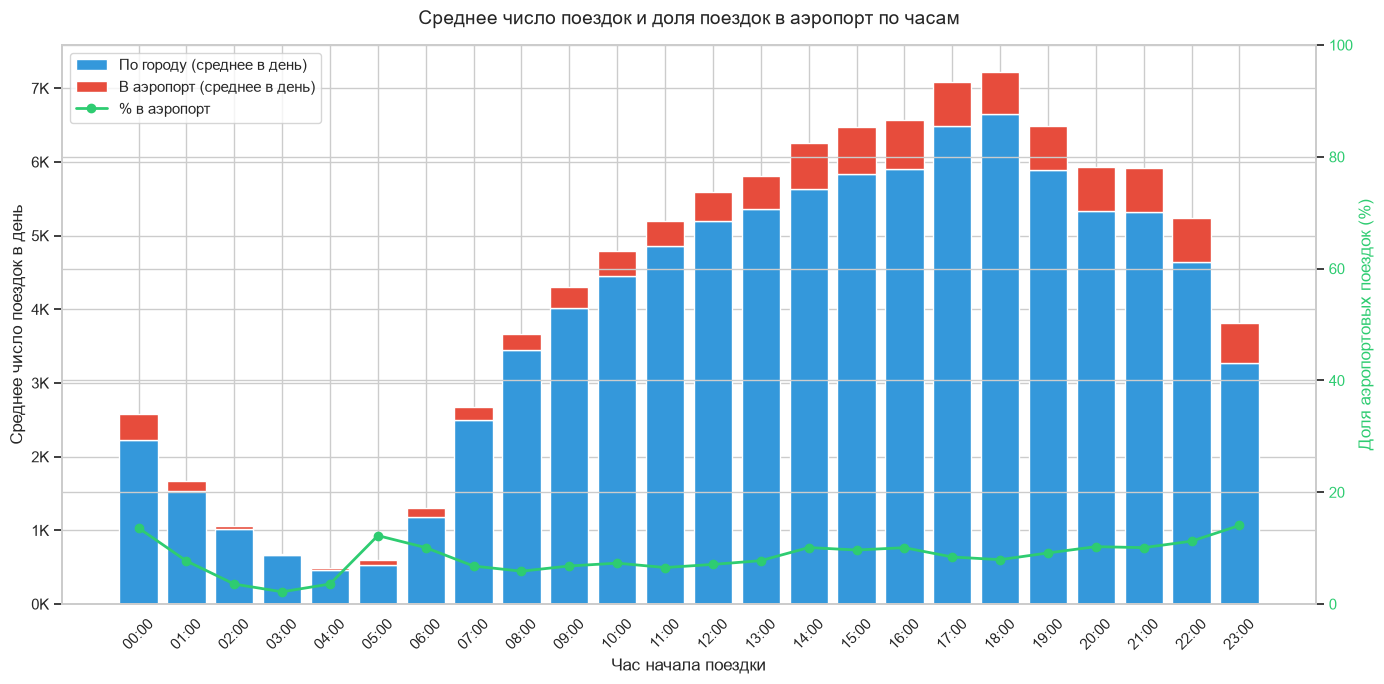

In [15]:
# Визуализация
fig, ax1 = plt.subplots(figsize=(14, 7))

x = hourly_combined["pickup_hour"]

bars_city = ax1.bar(
    x,
    hourly_combined["avg_city_trips_per_day"],
    color="#3498db",
    edgecolor="white",
    label="Поездки по городу (среднее в день)",
)

bars_airport = ax1.bar(
    x,
    hourly_combined["avg_airport_trips_per_day"],
    bottom=hourly_combined["avg_city_trips_per_day"],
    color="#e74c3c",
    edgecolor="white",
    label="Поездки в аэропорт (среднее в день)",
)

ax1.set_xlabel("Час начала поездки", fontsize=12)
ax1.set_ylabel("Среднее число поездок в день", fontsize=12)
ax1.set_title(
    "Среднее число поездок и доля поездок в аэропорт по часам",
    fontsize=14, pad=15,
)
ax1.set_xticks(range(24))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# Форматтер для оси Y (показываем тысячи)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Доля аэропортовых на второй оси
ax2 = ax1.twinx()
ax2.plot(
    hourly_combined["pickup_hour"],
    hourly_combined["airport_share"],
    color="#2ecc71",
    marker="o",
    linewidth=2,
    label="Доля аэропортовых поездок (%)",
)
ax2.set_ylabel("Доля аэропортовых поездок (%)", color="#2ecc71", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#2ecc71")
ax2.set_ylim(0, 100)

# Легенда
legend_elements = [
    Patch(facecolor="#3498db", label="По городу (среднее в день)"),
    Patch(facecolor="#e74c3c", label="В аэропорт (среднее в день)"),
    Line2D([0], [0], color="#2ecc71", lw=2, marker="o", label="% в аэропорт"),
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# Сводка по часам с максимумом аэропортовых поездок
print("=" * 60)
print("Анализ поездок в аэропорт по часам (средние значения в день)")
print("=" * 60)

print("\nТоп-5 часов с наибольшим количеством поездок в аэропорт (среднее в день):")
top_airport = hourly_combined.nlargest(5, "avg_airport_trips_per_day")
for _, row in top_airport.iterrows():
    print(
        f"  {int(row['pickup_hour']):02d}:00 - "
        f"{row['avg_airport_trips_per_day']:.1f} поездок в день "
        f"({row['airport_share']:.1f}% от всех поездок в этот час), "
        f"ср. цена ${row['avg_airport_fare']:.2f}"
    )

print("\nТоп-5 часов с наибольшей ДОЛЕЙ аэропортовых поездок (среди часов > 100 поездок в день):")
filtered_share = hourly_combined[hourly_combined["avg_trips_per_day"] > 100].nlargest(5, "airport_share")
for _, row in filtered_share.iterrows():
    print(
        f"  {int(row['pickup_hour']):02d}:00 - "
        f"{row['airport_share']:.1f}% аэропорт "
        f"({row['avg_airport_trips_per_day']:.1f} из {row['avg_trips_per_day']:.1f} в день)"
    )

print("\nОбщая статистика (средние значения в день):")
avg_total_trips = hourly_combined["avg_trips_per_day"].sum()
avg_airport_trips = hourly_combined["avg_airport_trips_per_day"].sum()
avg_city_trips = hourly_combined["avg_city_trips_per_day"].sum()
print(f"  Среднее число поездок в день: {avg_total_trips:,.1f}")
print(f"  Среднее число поездок в аэропорт в день: {avg_airport_trips:,.1f} ({avg_airport_trips/avg_total_trips*100:.1f}%)")
print(f"  Среднее число поездок по городу в день: {avg_city_trips:,.1f}")

Анализ поездок в аэропорт по часам (средние значения в день)

Топ-5 часов с наибольшим количеством поездок в аэропорт (среднее в день):
  16:00 — 661.4 поездок в день (10.1% от всех поездок в этот час), ср. цена $65.64
  14:00 — 632.7 поездок в день (10.1% от всех поездок в этот час), ср. цена $58.09
  15:00 — 624.9 поездок в день (9.7% от всех поездок в этот час), ср. цена $59.92
  20:00 — 609.3 поездок в день (10.3% от всех поездок в этот час), ср. цена $55.20
  21:00 — 595.9 поездок в день (10.1% от всех поездок в этот час), ср. цена $52.71

Топ-5 часов с наибольшей ДОЛЕЙ аэропортовых поездок (среди часов > 100 поездок в день):
  23:00 — 14.1% аэропорт (535.3 из 3808.0 в день)
  00:00 — 13.6% аэропорт (350.9 из 2579.4 в день)
  05:00 — 12.2% аэропорт (73.7 из 602.0 в день)
  22:00 — 11.2% аэропорт (588.7 из 5233.5 в день)
  20:00 — 10.3% аэропорт (609.3 из 5937.7 в день)

Общая статистика (средние значения в день):
  Среднее число поездок в день: 101,384.7
  Среднее число поездок в 

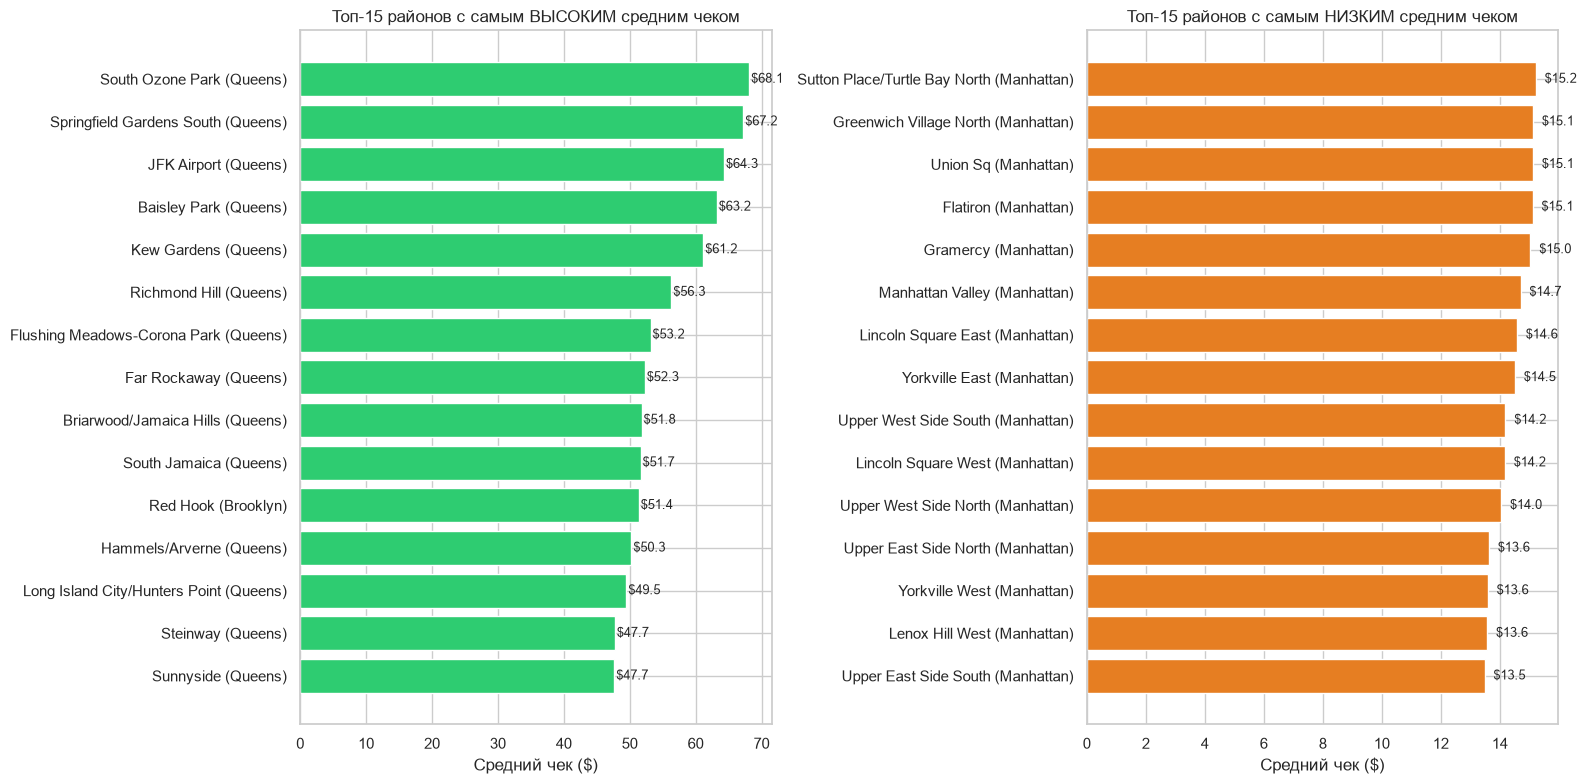

In [17]:
import requests, io

ZONES_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones = pd.read_csv(io.StringIO(requests.get(ZONES_URL).text))
zones = zones.rename(columns={"LocationID": "PULocationID", "Zone": "zone_name", "Borough": "borough"})

# Район с максимальным средним чеком (не менее 1 000 поездок)
zone_stats = (
    clean_taxi
    .groupby("PULocationID")
    .agg(trips=("fare_amount", "size"), avg_fare=("fare_amount", "mean"))
    .reset_index()
    .merge(zones[["PULocationID", "zone_name", "borough"]], on="PULocationID", how="left")
)

zone_stats = zone_stats[
    (zone_stats["trips"] >= 1_000)
    & zone_stats["zone_name"].notna()
    & zone_stats["borough"].notna() 
].copy()

zone_stats["label"] = zone_stats["zone_name"] + " (" + zone_stats["borough"] + ")"

# Топ-15 дорогих и топ-15 дешёвых
top_exp   = zone_stats.nlargest(15, "avg_fare").sort_values("avg_fare")
top_cheap = zone_stats.nsmallest(15, "avg_fare").sort_values("avg_fare")

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=False)

# Дорогие районы
axes[0].barh(top_exp["label"], top_exp["avg_fare"], color="#2ecc71", edgecolor="white")
axes[0].set_title("Топ-15 районов с самым ВЫСОКИМ средним чеком", fontsize=12)
axes[0].set_xlabel("Средний чек ($)")
for x, y in zip(top_exp["avg_fare"], top_exp["label"]):
    axes[0].text(x + 0.3, y, f"${x:.1f}", va="center", fontsize=9)

# Дешёвые районы 
axes[1].barh(top_cheap["label"], top_cheap["avg_fare"], color="#e67e22", edgecolor="white")
axes[1].set_title("Топ-15 районов с самым НИЗКИМ средним чеком", fontsize=12)
axes[1].set_xlabel("Средний чек ($)")
for x, y in zip(top_cheap["avg_fare"], top_cheap["label"]):
    axes[1].text(x + 0.3, y, f"${x:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Безналичных поездок: 8,014,458 из 9,225,994 (86.9%)


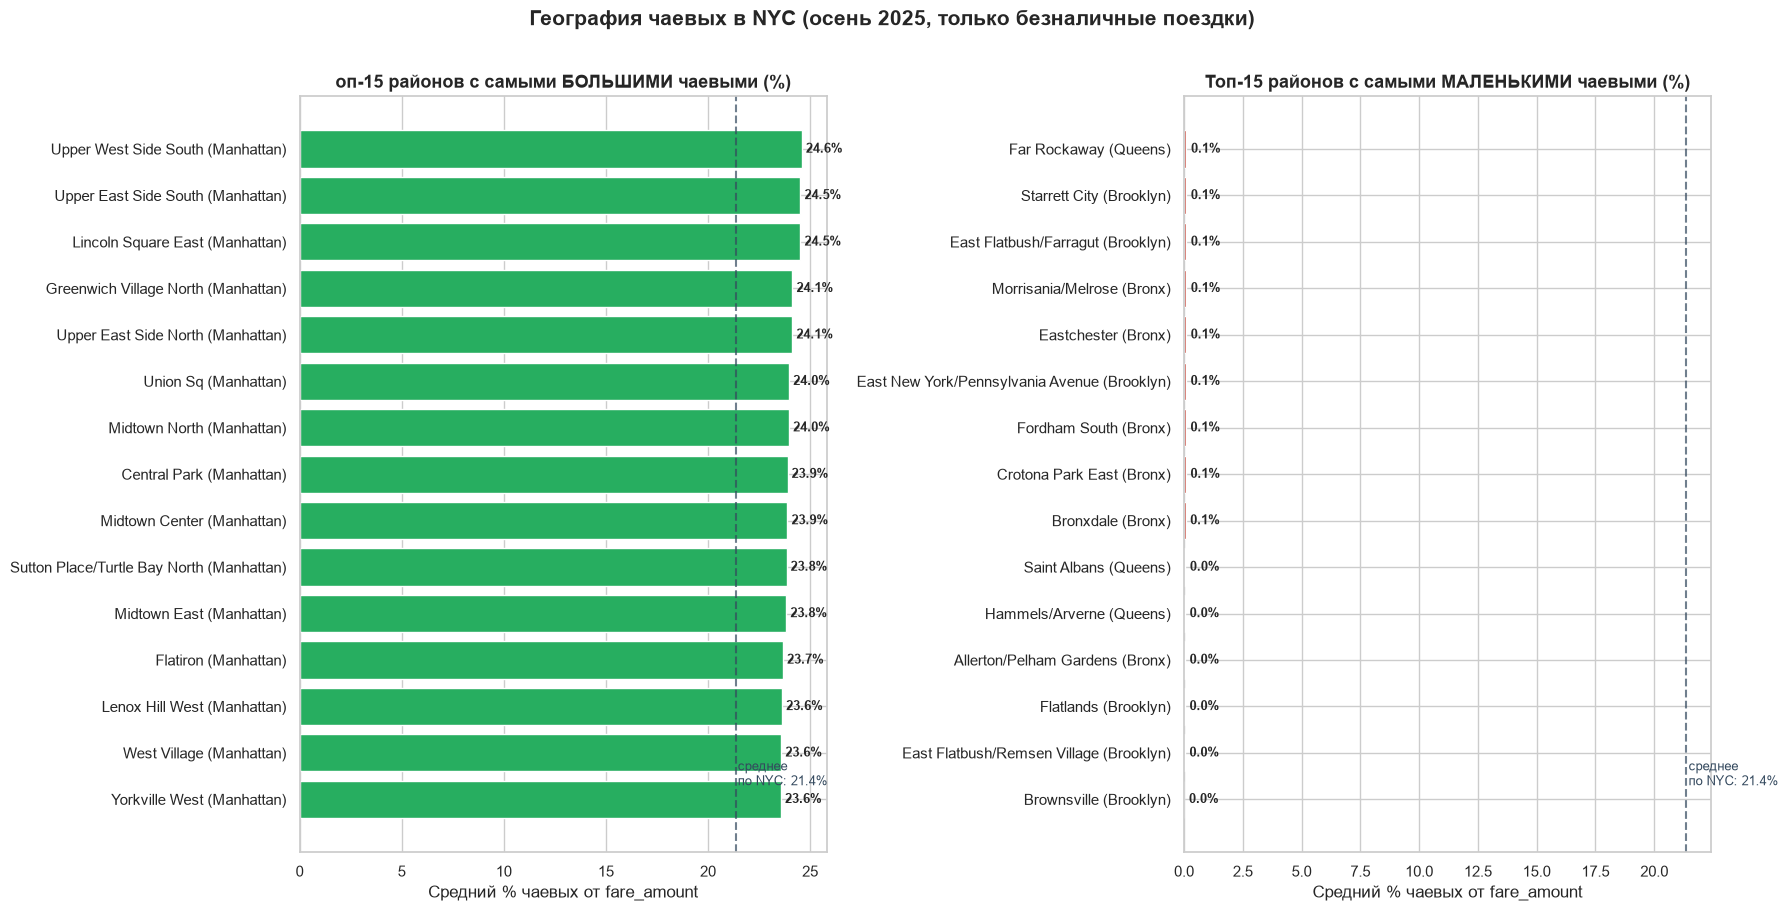

In [18]:
# Фильтруем только безналичные поездки (payment_type == 1)
# Именно для них tip_amount заполняется автоматически и честно
card_taxi = clean_taxi[clean_taxi["payment_type"] == 1].copy()
print(f"Безналичных поездок: {len(card_taxi):,} из {len(clean_taxi):,} ({len(card_taxi)/len(clean_taxi)*100:.1f}%)")

# Агрегация по районам
tip_stats = (
    card_taxi
    .groupby("PULocationID")
    .agg(
        trips=("fare_amount", "size"),
        avg_fare=("fare_amount", "mean"),
        avg_tip=("tip_amount", "mean"),
        total_fare=("fare_amount", "sum"),
        total_tip=("tip_amount", "sum"),
    )
    .reset_index()
    .merge(zones[["PULocationID", "zone_name", "borough"]], on="PULocationID", how="left")
)

# Фильтр: минимум 500 поездок + известные зоны
tip_stats = tip_stats[
    (tip_stats["trips"] >= 500)
    & tip_stats["zone_name"].notna()
    & tip_stats["borough"].notna()
].copy()

# Ключевая метрика: процент чаевых от стоимости поездки
tip_stats["tip_pct"] = tip_stats["total_tip"] / tip_stats["total_fare"] * 100
tip_stats["label"] = tip_stats["zone_name"] + " (" + tip_stats["borough"] + ")"

# Топ-15 щедрых и скупых районов
top_generous = tip_stats.nlargest(15, "tip_pct").sort_values("tip_pct")
top_stingy   = tip_stats.nsmallest(15, "tip_pct").sort_values("tip_pct")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Щедрые районы
bars1 = axes[0].barh(top_generous["label"], top_generous["tip_pct"],
                     color="#27ae60", edgecolor="white")
axes[0].set_title("оп-15 районов с самыми БОЛЬШИМИ чаевыми (%)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Средний % чаевых от fare_amount")
for x, y in zip(top_generous["tip_pct"], top_generous["label"]):
    axes[0].text(x + 0.2, y, f"{x:.1f}%", va="center", fontsize=9, fontweight="bold")

# Скупые районы
bars2 = axes[1].barh(top_stingy["label"], top_stingy["tip_pct"],
                     color="#c0392b", edgecolor="white")
axes[1].set_title("Топ-15 районов с самыми МАЛЕНЬКИМИ чаевыми (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Средний % чаевых от fare_amount")
for x, y in zip(top_stingy["tip_pct"], top_stingy["label"]):
    axes[1].text(x + 0.2, y, f"{x:.1f}%", va="center", fontsize=9, fontweight="bold")

# Общая линия среднего по городу
city_tip_pct = card_taxi["tip_amount"].sum() / card_taxi["fare_amount"].sum() * 100
for ax in axes:
    ax.axvline(city_tip_pct, color="#34495e", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.text(city_tip_pct + 0.1, ax.get_ylim()[1] * 0.02,
            f"среднее\nпо NYC: {city_tip_pct:.1f}%",
            fontsize=9, color="#34495e")

plt.suptitle("География чаевых в NYC (осень 2025, только безналичные поездки)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [19]:
print("ТОП-5 РАЙОНОВ С ВЫСОКИМИ ЧАЕВЫМИ")
for _, r in tip_stats.nlargest(5, "tip_pct").iterrows():
    print(f"- {r['label']}: {r['tip_pct']:.1f}% (ср. чек ${r['avg_fare']:.1f}, поездок: {r['trips']:,})")

print("\nТОП-5 С НИЗКИМИ ЧАЕВЫМИ")
for _, r in tip_stats.nsmallest(5, "tip_pct").iterrows():
    print(f"- {r['label']}: {r['tip_pct']:.1f}% (ср. чек ${r['avg_fare']:.1f}, поездок: {r['trips']:,})")

print(f"\nВ среднем по NYC: {city_tip_pct:.1f}% чаевых от fare")

ТОП-5 РАЙОНОВ С ВЫСОКИМИ ЧАЕВЫМИ
- Upper West Side South (Manhattan): 24.6% (ср. чек $14.3, поездок: 213,687)
- Upper East Side South (Manhattan): 24.5% (ср. чек $13.6, поездок: 444,565)
- Lincoln Square East (Manhattan): 24.5% (ср. чек $14.7, поездок: 259,393)
- Greenwich Village North (Manhattan): 24.1% (ср. чек $15.2, поездок: 115,894)
- Upper East Side North (Manhattan): 24.1% (ср. чек $13.7, поездок: 374,847)

ТОП-5 С НИЗКИМИ ЧАЕВЫМИ
- Brownsville (Brooklyn): 0.0% (ср. чек $33.1, поездок: 4,549)
- East Flatbush/Remsen Village (Brooklyn): 0.0% (ср. чек $30.7, поездок: 3,388)
- Flatlands (Brooklyn): 0.0% (ср. чек $32.6, поездок: 3,512)
- Allerton/Pelham Gardens (Bronx): 0.0% (ср. чек $41.1, поездок: 643)
- Hammels/Arverne (Queens): 0.0% (ср. чек $50.3, поездок: 2,023)

В среднем по NYC: 21.4% чаевых от fare


In [20]:
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"
LATITUDE = 40.779   # Central Park, NYC
LONGITUDE = -73.969

print("Downloading weather data...")

# Определяем диапазон: с 1 сентября
start = pd.Timestamp(year=YEAR, month=9, day=1)
# по 30 ноября (MonthEnd(0) сдвигает дату на конец текущего месяца)
end = pd.Timestamp(year=YEAR, month=11, day=1) + pd.offsets.MonthEnd(0)

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start.strftime("%Y-%m-%d"),  # 2025-09-01
    "end_date": end.strftime("%Y-%m-%d"),      # 2025-11-30
    "hourly": "precipitation,rain",
    "timezone": "America/New_York", # Важно! Время такси в NY тоже хранится в локальном времени.
}

response = requests.get(WEATHER_URL, params=params)
response.raise_for_status()

weather_json = response.json()

weather = pd.DataFrame({
    "pickup_hour": pd.to_datetime(weather_json["hourly"]["time"]),
    "precipitation_mm": weather_json["hourly"]["precipitation"],
    "rain_mm": weather_json["hourly"]["rain"],
})

print(f"Weather rows: {len(weather):,}")
weather.head()

Weather rows: 2,184


,pickup_hour,precipitation_mm,rain_mm
0,2025-09-01 00:00:00,0.0,0.0
1,2025-09-01 01:00:00,0.0,0.0
2,2025-09-01 02:00:00,0.0,0.0
3,2025-09-01 03:00:00,0.0,0.0
4,2025-09-01 04:00:00,0.0,0.0


In [21]:
clean_taxi["pickup_hour"] = clean_taxi["tpep_pickup_datetime"].dt.floor("h")

# Агрегация по datetime-часу
hourly_taxi = (
    clean_taxi
    .groupby("pickup_hour")                   # datetime-ключ
    .agg(
        trips=("fare_amount", "size"),
        avg_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        avg_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration_min", "mean"),
    )
    .reset_index()
)

# Отдельная колонка для графиков «час суток»
hourly_taxi["hour_of_day"] = hourly_taxi["pickup_hour"].dt.hour

# Merge с погодой
hourly = (
    hourly_taxi
    .merge(weather, on="pickup_hour", how="left")
    .sort_values("pickup_hour")
    .reset_index(drop=True)
)

hourly["is_raining"] = hourly["rain_mm"].fillna(0) > 0

print(f"Merged rows: {len(hourly)}, weather NaN: {hourly['rain_mm'].isna().sum()}")
print("\nHOURLY DATA")
hourly.head()

Merged rows: 2184, weather NaN: 0

HOURLY DATA


,pickup_hour,trips,avg_fare,median_fare,avg_distance,avg_duration,hour_of_day,precipitation_mm,rain_mm,is_raining
0,2025-09-01 00:00:00,2278,23.298630,14.9,4.913411,14.433524,0,0.0,0.0,False
1,2025-09-01 01:00:00,1345,21.142454,13.5,4.398773,13.348501,1,0.0,0.0,False
2,2025-09-01 02:00:00,770,18.462519,12.1,3.666688,11.425411,2,0.0,0.0,False
3,2025-09-01 03:00:00,506,20.650909,13.5,3.986107,12.097431,3,0.0,0.0,False
4,2025-09-01 04:00:00,425,26.030871,17.0,5.139694,13.382902,4,0.0,0.0,False


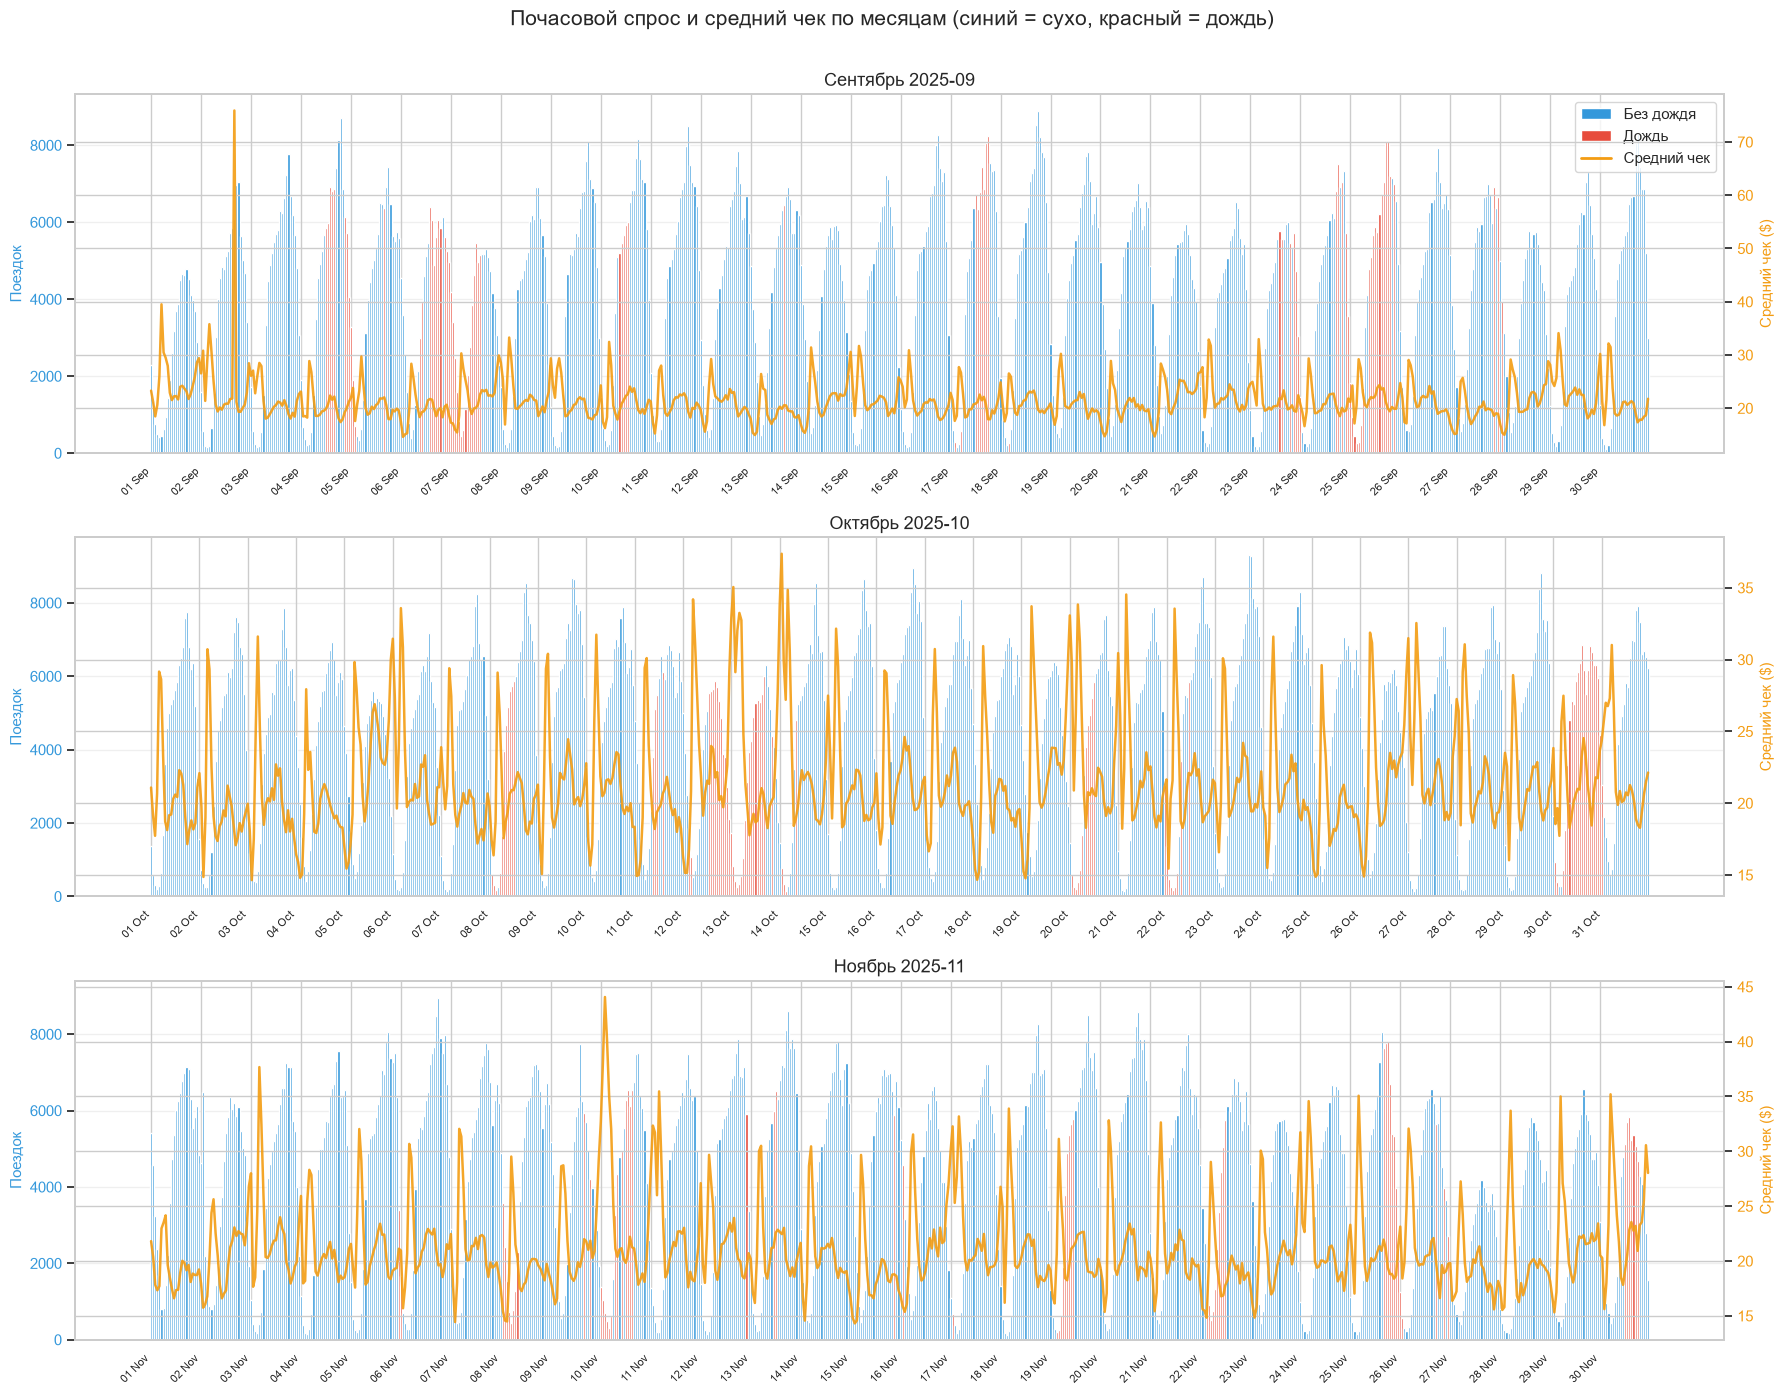

In [ ]:
# Готовим данные: месяц + флаг дождя
hourly["month"] = hourly["pickup_hour"].dt.to_period("M").astype(str)  # "2025-09"
hourly["x_label"] = hourly["pickup_hour"].dt.strftime("%d %b %H:%M")

months = sorted(hourly["month"].unique())
month_names = {"2025-09": "Сентябрь", "2025-10": "Октябрь", "2025-11": "Ноябрь"}

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=False)
fig.suptitle(
    "Почасовой спрос и средний чек по месяцам (синий = сухо, красный = дождь)",
    fontsize=15, y=0.995,
)

for ax, m in zip(axes, months):
    data = hourly[hourly["month"] == m].sort_values("pickup_hour").copy()

    # Цвет столбцов
    colors = ["#e74c3c" if r else "#3498db" for r in data["is_raining"]]

    # Столбцы
    x_pos = range(len(data))
    bars = ax.bar(
        x_pos,
        data["trips"],
        color=colors,
        edgecolor="white",
        width=1.0,
    )

    # Подписи оси X - каждые 24 часа (каждый день)
    tick_pos = list(range(0, len(data), 24))
    tick_labels = [data.iloc[i]["pickup_hour"].strftime("%d %b") for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    ax.set_ylabel("Поездок", color="#3498db", fontsize=11)
    ax.tick_params(axis="y", labelcolor="#3498db")
    ax.set_title(f"{month_names[m]} {m}", fontsize=13)

    # Правая ось - средний чек
    ax2 = ax.twinx()
    ax2.plot(
        x_pos,
        data["avg_fare"],
        color="#f39c12",
        linewidth=1.8,
        alpha=0.9,
    )
    ax2.set_ylabel("Средний чек ($)", color="#f39c12", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="#f39c12")

    # Общая сетка + легенда
    ax.grid(axis="y", alpha=0.3)
    if m == months[0]:
        ax.legend(
            handles=[
                Patch(facecolor="#3498db", label="Без дождя"),
                Patch(facecolor="#e74c3c", label="Дождь"),
                Line2D([0], [0], color="#f39c12", lw=2, label="Средний чек"),
            ],
            loc="upper right",
            frameon=True,
        )

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Фильтруем только безналичные поездки
card_trips = clean_taxi[clean_taxi["payment_type"] == 1].copy()
print(f"Безналичных поездок: {len(card_trips):,}")

# Создаём datetime-час для мержа с погодой (округляем до часа)
card_trips["pickup_hour_dt"] = card_trips["tpep_pickup_datetime"].dt.floor("h")

# Мержим каждую поездку с погодой по datetime-часу
trips_with_weather = card_trips.merge(
    weather[["pickup_hour", "rain_mm"]],
    left_on="pickup_hour_dt",   # <-- datetime из поездок
    right_on="pickup_hour",     # <-- datetime из погоды
    how="left",
)

# Флаг дождя
trips_with_weather["is_raining"] = trips_with_weather["rain_mm"] > 0

# Считаем процент чаевых
trips_with_weather["tip_pct"] = (
    trips_with_weather["tip_amount"] / trips_with_weather["fare_amount"] * 100
)

# Убираем выбросы (> 50% чаевых) и отрицательные значения
tips_df = trips_with_weather[
    (trips_with_weather["tip_pct"] >= 0)
    & (trips_with_weather["tip_pct"] <= 50)
].copy()

# Бакет дистанции для контроля
tips_df["dist_bucket"] = pd.cut(
    tips_df["trip_distance"],
    bins=[0, 2, 5, 10, 50],
    labels=["<2mi", "2-5mi", "5-10mi", "10+mi"],
)

print(f"После фильтрации: {len(tips_df):,} поездок")
print(f"Из них в дождь: {tips_df['is_raining'].sum():,}")

# Сводная статистика
tip_summary = (
    tips_df
    .groupby("is_raining")
    .agg(
        n_trips=("tip_pct", "size"),
        mean_tip_pct=("tip_pct", "mean"),
        median_tip_pct=("tip_pct", "median"),
        std_tip_pct=("tip_pct", "std"),
        mean_fare=("fare_amount", "mean"),
        mean_distance=("trip_distance", "mean"),
    )
    .round(2)
)
tip_summary.index = ["Без дождя", "Дождь"]
print("\nОБЩАЯ СВОДКА")
print(tip_summary)

# Визуализация: общий violin + box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Общий
sns.violinplot(
    data=tips_df,
    x="is_raining",
    y="tip_pct",
    hue="is_raining",
    palette={False: "#3498db", True: "#e74c3c"},
    inner="box",
    ax=axes[0],
    legend=False,
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Без дождя", "Дождь"])
axes[0].set_ylabel("Чаевые (%)")
axes[0].set_title("Распределение чаевых: дождь vs без дождя")
axes[0].set_ylim(0, 40)

# По бакетам дистанции - контроль confounder'а
sns.boxplot(
    data=tips_df,
    x="dist_bucket",
    y="tip_pct",
    hue="is_raining",
    palette={False: "#3498db", True: "#e74c3c"},
    ax=axes[1],
)
axes[1].set_xlabel("Дистанция поездки")
axes[1].set_ylabel("Чаевые (%)")
axes[1].set_title("Чаевые по дистанциям (синий=сухо, красный=дождь)")
axes[1].set_ylim(0, 40)
axes[1].legend(title="Дождь", loc="upper right")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'scipy'

In [ ]:
print("\nЧАЕВЫЕ ПО ДИСТАНЦИЯМ")
detail = (
    tips_df
    .groupby(["dist_bucket", "is_raining"])
    .agg(
        trips=("tip_pct", "size"),
        mean_tip_pct=("tip_pct", "mean"),
        median_tip_pct=("tip_pct", "median"),
    )
    .round(2)
)
detail.index = detail.index.set_levels(
    detail.index.levels[1].map({False: "сухо", True: "дождь"}),
    level=1,
)
print(detail)


ЧАЕВЫЕ ПО ДИСТАНЦИЯМ
                          trips  mean_tip_pct  median_tip_pct
dist_bucket is_raining                                       
<2mi        сухо        3936031         26.90           28.88
            дождь        481001         26.52           28.49
2-5mi       сухо        1843035         21.61           24.72
            дождь        209130         21.33           24.48
5-10mi      сухо         641891         18.73           22.93
            дождь         74401         18.47           22.81
10+mi       сухо         633610         16.97           21.36
            дождь         76972         16.94           21.36


In [ ]:
# ============================================================
# LOAD INTO DUCKDB - ВСЕ АГГРЕГАЦИИ
# ============================================================
print("\nLoading into DuckDB...")

con = duckdb.connect()

# ── 1. Почасовая агрегация с погодой ──
con.register("hourly_df", hourly)
con.execute("""
    CREATE OR REPLACE TABLE hourly_taxi_weather AS
    SELECT * FROM hourly_df
""")

# ── 2. Чаевые по районам ──
con.register("tip_stats_df", tip_stats)
con.execute("""
    CREATE OR REPLACE TABLE tip_by_zone AS
    SELECT * FROM tip_stats_df
""")

# ── 3. Поездки в аэропорт по часам ──
con.register("airport_df", hourly_combined)
con.execute("""
    CREATE OR REPLACE TABLE airport_by_hour AS
    SELECT * FROM airport_df
""")

# ── 4. Статистика по дням недели ──
con.register("dow_df", dow_stats)
con.execute("""
    CREATE OR REPLACE TABLE day_of_week_stats AS
    SELECT * FROM dow_df
""")

# ── 5. Чаевые по дистанциям (дождь vs сухо) ──
con.register("tips_detail_df", detail.reset_index())
con.execute("""
    CREATE OR REPLACE TABLE tips_by_distance AS
    SELECT * FROM tips_detail_df
""")


print("All tables loaded successfully.")
print(con.execute("SHOW TABLES").df())


Loading into DuckDB...
All tables loaded successfully.
                  name
0      airport_by_hour
1           airport_df
2    day_of_week_stats
3               dow_df
4            hourly_df
5  hourly_taxi_weather
6          tip_by_zone
7         tip_stats_df
8     tips_by_distance
9       tips_detail_df


In [ ]:
# ============================================================
# COMPREHENSIVE REPORT
# ============================================================
print("\n" + "=" * 60)
print("           ИТОГОВЫЙ ОТЧЁТ: NYC TAXI, ОСЕНЬ 2025")
print("=" * 60)

# Дождь vs без дождя
rain_report = con.execute("""
    SELECT
        is_raining,
        COUNT(*) AS hours,
        COUNT(DISTINCT DATE(pickup_hour)) AS days,
        SUM(trips) AS total_trips,
        ROUND(SUM(trips) / NULLIF(COUNT(DISTINCT DATE(pickup_hour)), 0), 0) AS avg_trips_per_day,
        ROUND(SUM(avg_fare * trips) / NULLIF(SUM(trips), 0), 2) AS weighted_avg_fare,
        ROUND(AVG(median_fare), 2) AS avg_median_fare,
        ROUND(SUM(avg_distance * trips) / NULLIF(SUM(trips), 0), 2) AS weighted_avg_distance,
        ROUND(SUM(avg_duration * trips) / NULLIF(SUM(trips), 0), 1) AS weighted_avg_duration
    FROM hourly_taxi_weather
    GROUP BY is_raining
    ORDER BY is_raining
""").df()
rain_report["condition"] = rain_report["is_raining"].map({False: "Без дождя", True: "Дождь"})
print("\n── ДОЖДЬ VS БЕЗ ДОЖДЯ ──")
print(rain_report[["condition","days","avg_trips_per_day","weighted_avg_fare",
                    "weighted_avg_distance","weighted_avg_duration"]].to_string(index=False))

# Пик и минимум спроса
peak = con.execute("""
    SELECT
        hour_of_day,
        COUNT(DISTINCT DATE(pickup_hour)) AS days,
        ROUND(SUM(trips) / NULLIF(COUNT(DISTINCT DATE(pickup_hour)), 0), 0) AS avg_trips_per_day,
        SUM(avg_fare * trips) / NULLIF(SUM(trips), 0) AS avg_fare
    FROM hourly_taxi_weather
    GROUP BY hour_of_day
    ORDER BY avg_trips_per_day DESC LIMIT 3
""").df()

print("\nТОП-3 ЧАСА ПО СПРОСУ (среднее число поездок в день)")
for _, r in peak.iterrows():
    print(f"  {int(r['hour_of_day']):02d}:00 → {int(r['avg_trips_per_day']):,} поездок/день, ср. чек ${r['avg_fare']:.2f}")


           ИТОГОВЫЙ ОТЧЁТ: NYC TAXI, ОСЕНЬ 2025

── ДОЖДЬ VS БЕЗ ДОЖДЯ ──
condition  days  avg_trips_per_day  weighted_avg_fare  weighted_avg_distance  weighted_avg_duration
Без дождя    91            90561.0              20.51                   3.52                   18.2
    Дождь    38            25920.0              20.81                   3.49                   18.8

ТОП-3 ЧАСА ПО СПРОСУ (среднее число поездок в день)
  18:00 → 7,226 поездок/день, ср. чек $19.23
  17:00 → 7,079 поездок/день, ср. чек $20.59
  16:00 → 6,563 поездок/день, ср. чек $22.71


In [ ]:
dow_report = con.execute("""
    SELECT dow_name, trips, avg_fare, median_fare
    FROM day_of_week_stats
    ORDER BY dow
""").df()
print("\n── ДНИ НЕДЕЛИ ──")
print(dow_report.to_string(index=False))


── ДНИ НЕДЕЛИ ──
 dow_name   trips  avg_fare  median_fare
   Monday 1184962 21.210656         14.2
  Tuesday 1325301 20.599271         14.2
Wednesday 1396866 20.438165         14.2
 Thursday 1424017 20.719081         14.9
   Friday 1387726 20.560505         14.2
 Saturday 1357527 19.248356         13.5
   Sunday 1149595 21.208779         13.5


In [ ]:
airport_report = con.execute("""
    SELECT
        SUM(airport_trips)                                        AS total_airport,
        SUM(trips)                                                AS total_all,
        ROUND(SUM(airport_trips) * 100.0 / SUM(trips), 1)        AS airport_share_pct,
        ROUND(AVG(avg_airport_fare), 2)                           AS avg_airport_fare
    FROM airport_by_hour
""").df()
print("\n── АЭРОПОРТ ──")
print(airport_report.to_string(index=False))


── АЭРОПОРТ ──
 total_airport  total_all  airport_share_pct  avg_airport_fare
      818107.0  9225994.0                8.9             55.32


In [ ]:
generous = con.execute("""
    SELECT label, ROUND(tip_pct,1) AS tip_pct, ROUND(avg_fare,1) AS avg_fare, trips
    FROM tip_by_zone
    ORDER BY tip_pct DESC LIMIT 5
""").df()
stingy = con.execute("""
    SELECT label, ROUND(tip_pct,1) AS tip_pct, ROUND(avg_fare,1) AS avg_fare, trips
    FROM tip_by_zone
    ORDER BY tip_pct ASC LIMIT 5
""").df()
print("\n── ТОП-5 РАЙОНОВ С ВЫСОКИМИ ЧАЕВЫМИ ──")
print(generous.to_string(index=False))
print("\n── ТОП-5 РАЙОНОВ С НИЗКИМИ ЧАЕВЫМИ ──")
print(stingy.to_string(index=False))

# Чаевые по дистанциям
tips_dist = con.execute("""
    SELECT dist_bucket, is_raining, trips,
           ROUND(mean_tip_pct, 2) AS mean_tip_pct,
           ROUND(median_tip_pct, 2) AS median_tip_pct
    FROM tips_by_distance
    ORDER BY dist_bucket, is_raining
""").df()
print("\n── ЧАЕВЫЕ ПО ДИСТАНЦИЯМ ──")
print(tips_dist.to_string(index=False))


── ТОП-5 РАЙОНОВ С ВЫСОКИМИ ЧАЕВЫМИ ──
                              label  tip_pct  avg_fare  trips
  Upper West Side South (Manhattan)     24.6      14.3 213687
    Lincoln Square East (Manhattan)     24.5      14.7 259393
  Upper East Side South (Manhattan)     24.5      13.6 444565
Greenwich Village North (Manhattan)     24.1      15.2 115894
  Upper East Side North (Manhattan)     24.1      13.7 374847

── ТОП-5 РАЙОНОВ С НИЗКИМИ ЧАЕВЫМИ ──
                                  label  tip_pct  avg_fare  trips
        Allerton/Pelham Gardens (Bronx)      0.0      41.1    643
                 Brownsville (Brooklyn)      0.0      33.1   4549
East Flatbush/Remsen Village (Brooklyn)      0.0      30.7   3388
                   Flatlands (Brooklyn)      0.0      32.6   3512
               Hammels/Arverne (Queens)      0.0      50.3   2023

── ЧАЕВЫЕ ПО ДИСТАНЦИЯМ ──
dist_bucket is_raining   trips  mean_tip_pct  median_tip_pct
       <2mi      дождь  481001         26.52           28.49
   